In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from rich import print
import os

Start server

bash neo4j/setup_neo4j.sh 

python neo4j/create_neo4j_graph.py --clear --queries --json-dir "/home/sga/Code/FAIRFluids/Workflows/paper_outputs"


In [2]:
#Connect to server
#Run query
#Get results
#Disconnect from server


# Neo4j connection parameters
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"  # Update with your password

# Connect to Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def test_connection():
    """Test the Neo4j connection"""
    with driver.session() as session:
        result = session.run("RETURN 1 as test")
        record = result.single()
        print(f"✅ Connected to Neo4j! Test result: {record['test']}")

test_connection()

✅ Connected to Neo4j! Test result: 1

In [3]:
# Probe-Query: schneller Datenbank-Check
probe_query = """
MATCH (e:Experiment)
RETURN count(e) AS experiment_count
"""

with driver.session() as session:
    probe_result = session.run(probe_query).single()

print(f"Probe erfolgreich: {probe_result['experiment_count']} Experimente in Neo4j gefunden.")

Probe erfolgreich: 837 Experimente in Neo4j gefunden.

In [4]:
# Define the Cypher query
# Find all measurements/experiments connected to water
# Note: In this graph, linked water is usually compoundID='compound_water' and pubChemID is often null.
query = """
MATCH (c:Compound)
WHERE toString(c.pubChemID) = '962'
   OR toLower(COALESCE(c.commonName, '')) = 'water'
   OR c.compoundID = 'compound_water'

MATCH (m)-[rcomp:HAS_COMPOUND]->(c)
OPTIONAL MATCH (m)-[rprop:HAS_PROPERTY]->(p:Property)

RETURN
  labels(m) AS measurement_labels,
  COALESCE(m.measurement_id, m.experiment_id, m.id, elementId(m)) AS measurement_id,
  c.compoundID AS compound_id,
  c.commonName AS compound_name,
  c.pubChemID AS compound_pubchem_id,
  toFloat(rcomp.mole_fraction) AS mole_fraction_water,

  p.propertyID AS property_id,
  p.propertyType AS property_type,
  p.phaseID AS phase_id,
  toFloat(rprop.value) AS property_value,
  toFloat(rprop.uncertainty) AS property_uncertainty,

  m.source_doi AS source_doi,
  m.source_file AS source_file
ORDER BY measurement_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

water_df = pd.DataFrame(records)

print(f"Retrieved {len(water_df)} records")
print("\nColumns:", list(water_df.columns))
print("\nFirst few rows:")
water_df.head(20)

Retrieved 1364 records

Columns:
[
    'measurement_labels',
    'measurement_id',
    'compound_id',
    'compound_name',
    'compound_pubchem_id',
    'mole_fraction_water',
    'property_id',
    'property_type',
    'phase_id',
    'property_value',
    'property_uncertainty',
    'source_doi',
    'source_file'
]

First few rows:

,measurement_labels,measurement_id,compound_id,compound_name,compound_pubchem_id,mole_fraction_water,property_id,property_type,phase_id,property_value,property_uncertainty,source_doi,source_file
0,[Experiment],02677a68-af3d-4d3c-90c2-c7dd15a5796d,compound_water,water,None,0.238100,None,viscosity,None,0.020110,0.000101,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
1,[Experiment],04067245-c28a-44e0-acbd-f97f96f5fe23,compound_water,water,None,0.799700,None,viscosity,None,0.011318,0.000057,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
2,[Experiment],0540119f-0979-4703-bb30-f22f7625cd80,compound_water,water,None,0.960200,None,viscosity,None,0.000521,0.000003,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
3,[Experiment],07bcddef-c4ce-4517-8fce-71ed42244e17,compound_water,water,None,0.108000,None,viscosity,None,0.039346,0.000197,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
4,[Experiment],09c9d17e-88fb-4259-bce1-999d1622c9be,compound_water,water,None,0.597800,None,viscosity,None,0.014735,0.000074,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
5,[Experiment],09f4f058-e219-4b6a-82c9-bf64006d1de3,compound_water,water,None,0.254364,None,viscosity,None,0.097130,0.001943,10.1016/j.jct.2018.07.031,Xu_Glycerol_Water.json
6,[Experiment],0b581945-80bf-432b-8f99-25b63f8dc129,compound_water,water,None,0.402200,None,viscosity,None,0.024091,0.000120,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
7,[Experiment],0c3d093e-6336-4d73-87f8-48338f21ee2d,compound_water,water,None,0.960200,None,viscosity,None,0.000819,0.000004,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
8,[Experiment],0c607824-f892-4be0-b9c7-348f5d7a8240,compound_water,water,None,0.597800,None,viscosity,None,0.003639,0.000018,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json
9,[Experiment],0daad1f4-40f8-436c-bfcd-2236ea3dd207,compound_water,water,None,0.960200,None,viscosity,None,0.000981,0.000005,10.1016/j.fluid.2014.01.028,Xu_Glycerol_Water.json


In [11]:
# Define the Cypher query
# Find ONLY pure water (water mole fraction = 1)
# Note: linked water in this graph is typically compoundID='compound_water' / commonName='water'
query = """
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: toString(c.pubChemID),
    compoundID: c.compoundID,
    commonName: toLower(COALESCE(c.commonName, '')),
    mole_fraction: toFloat(rcomp.mole_fraction)
}) AS compounds
WHERE ANY(c IN compounds
          WHERE (c.pubChemID = '962' OR c.compoundID = 'compound_water' OR c.commonName = 'water')
            AND c.mole_fraction = 1.0)

OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(COALESCE(param.parameter, '')) CONTAINS 'temperature'
   OR toLower(COALESCE(param.parameterID, '')) CONTAINS 'temperature'
WITH e, compounds,
     [c IN compounds
      WHERE c.pubChemID = '962' OR c.compoundID = 'compound_water' OR c.commonName = 'water'
      | c.mole_fraction][0] AS mole_fraction_water,
     COALESCE(
       [v IN collect(DISTINCT toFloat(rparam.value)) WHERE v IS NOT NULL][0],
       toFloat(e.param_temperature)
     ) AS temperature

OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE toLower(COALESCE(p.propertyType, '')) CONTAINS 'viscosity'
WITH e, mole_fraction_water, temperature,
     COALESCE(toFloat(rprop.value), toFloat(e.prop_viscosity)) AS property_value,
     toFloat(rprop.uncertainty) AS property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') AS property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

RETURN DISTINCT
       e.experiment_id AS experiment_id,
       property_type,
       property_value,
       property_uncertainty,
       null AS mole_fraction_glycerol,
       mole_fraction_water,
       null AS mole_fraction_cholinechloride,
       temperature,
       e.method AS method,
       e.source_file AS source_file,
       e.source_doi AS source_doi
ORDER BY e.experiment_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

water_df = pd.DataFrame(records)

print(f"Retrieved {len(water_df)} records")
print(f"\nFirst few rows:")
water_df

Retrieved 9 records

First few rows:

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi
0,17106d06-1cd7-4dcb-8de7-e4e8bc623c44,viscosity,0.000984,0.000005,None,1.0,None,293.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
1,3b1ff6df-7039-4f7c-9d9f-e6b6b480af29,viscosity,0.000477,0.000002,None,1.0,None,333.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
2,4ccfc557-3af1-4d14-a611-5a580a66b133,viscosity,0.000791,0.000004,None,1.0,None,303.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
3,54a37cda-99b2-4c5f-a5d0-3e557a971879,viscosity,0.000549,0.000003,None,1.0,None,323.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
4,5e7164a7-4386-47a8-8d1d-ecaa00544d23,viscosity,0.000386,0.000002,None,1.0,None,353.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
5,715401f2-50e7-4bcd-b37e-4b2457e83920,viscosity,0.000649,0.000003,None,1.0,None,313.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
6,829fe908-3c8c-4875-89ad-ec2e218c6ddc,viscosity,0.001274,0.000006,None,1.0,None,283.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
7,9cb4d0d9-5182-40fe-b9de-8f752878a443,viscosity,0.000435,0.000002,None,1.0,None,343.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
8,e58b323b-1099-462b-80a0-b23e2f9934e9,viscosity,0.000331,0.000002,None,1.0,None,363.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028


In [13]:
# Define the Cypher query
# Find ONLY Glycerol + Choline chloride (no water), solvent amount ratio == 2
# Glycerol = 753, Choline chloride = 6209, Water = 962
query = """
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: toString(c.pubChemID),
    compoundID: c.compoundID,
    commonName: c.commonName,
    mole_fraction: toFloat(rcomp.mole_fraction)
}) AS compounds
WHERE size(compounds) = 2
  AND ANY(c IN compounds WHERE c.pubChemID = '753')
  AND ANY(c IN compounds WHERE c.pubChemID = '6209')
  AND NOT ANY(c IN compounds WHERE c.pubChemID = '962')

OPTIONAL MATCH (e)-[rparamRatio:HAS_PARAMETER]->(paramRatio:Parameter)
WHERE toLower(COALESCE(paramRatio.parameter, '')) CONTAINS 'solvent'
  AND toLower(COALESCE(paramRatio.parameter, '')) CONTAINS 'amount ratio'
WITH e, compounds,
     [c IN compounds WHERE c.pubChemID = '753' | c.mole_fraction][0] AS mole_fraction_glycerol,
     0.0 AS mole_fraction_water,
     [c IN compounds WHERE c.pubChemID = '6209' | c.mole_fraction][0] AS mole_fraction_cholinechloride,
     [v IN collect(DISTINCT toFloat(rparamRatio.value)) WHERE v IS NOT NULL][0] AS solvent_ratio
WHERE solvent_ratio = 2.0

OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(COALESCE(param.parameter, '')) CONTAINS 'temperature'
   OR toLower(COALESCE(param.parameterID, '')) CONTAINS 'temperature'
WITH e, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride,
     COALESCE(
       [v IN collect(DISTINCT toFloat(rparam.value)) WHERE v IS NOT NULL][0],
       toFloat(e.param_temperature)
     ) AS temperature

OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE toLower(COALESCE(p.propertyType, '')) CONTAINS 'viscosity'
WITH e, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride, temperature,
     COALESCE(toFloat(rprop.value), toFloat(e.prop_viscosity)) AS property_value,
     toFloat(rprop.uncertainty) AS property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') AS property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

RETURN DISTINCT
       e.experiment_id AS experiment_id,
       property_type,
       property_value,
       property_uncertainty,
       mole_fraction_glycerol,
       mole_fraction_water,
       mole_fraction_cholinechloride,
       temperature,
       e.method AS method,
       e.source_file AS source_file,
       e.source_doi AS source_doi
ORDER BY e.experiment_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

des_pure_df = pd.DataFrame(records)

print(f"Retrieved {len(des_pure_df)} records")
print(f"\nFirst few rows:")
des_pure_df

Retrieved 0 records

First few rows:

""


In [7]:
# Define the Cypher query
# Find experiments with Glycerol + Choline chloride + Water (all 3 compounds), solvent ratio == 2
# Glycerol = 753, Choline chloride = 6209, Water = 962
query = """
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: toString(c.pubChemID),
    compoundID: c.compoundID,
    commonName: c.commonName,
    mole_fraction: toFloat(rcomp.mole_fraction)
}) AS compounds
WHERE size(compounds) = 3
  AND ANY(c IN compounds WHERE c.pubChemID = '753')
  AND ANY(c IN compounds WHERE c.pubChemID = '6209')
  AND ANY(c IN compounds WHERE c.pubChemID = '962')

OPTIONAL MATCH (e)-[rparamRatio:HAS_PARAMETER]->(paramRatio:Parameter)
WHERE toLower(COALESCE(paramRatio.parameter, '')) CONTAINS 'solvent'
  AND toLower(COALESCE(paramRatio.parameter, '')) CONTAINS 'amount ratio'
WITH e, compounds,
     [c IN compounds WHERE c.pubChemID = '753' | c.mole_fraction][0] AS mole_fraction_glycerol,
     [c IN compounds WHERE c.pubChemID = '962' | c.mole_fraction][0] AS mole_fraction_water,
     [c IN compounds WHERE c.pubChemID = '6209' | c.mole_fraction][0] AS mole_fraction_cholinechloride,
     [v IN collect(DISTINCT toFloat(rparamRatio.value)) WHERE v IS NOT NULL][0] AS solvent_ratio
WHERE solvent_ratio = 2.0

OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(COALESCE(param.parameter, '')) CONTAINS 'temperature'
   OR toLower(COALESCE(param.parameterID, '')) CONTAINS 'temperature'
WITH e, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride,
     COALESCE(
       [v IN collect(DISTINCT toFloat(rparam.value)) WHERE v IS NOT NULL][0],
       toFloat(e.param_temperature)
     ) AS temperature

OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE toLower(COALESCE(p.propertyType, '')) CONTAINS 'viscosity'
WITH e, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride, temperature,
     COALESCE(toFloat(rprop.value), toFloat(e.prop_viscosity)) AS property_value,
     toFloat(rprop.uncertainty) AS property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') AS property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

RETURN DISTINCT
       e.experiment_id AS experiment_id,
       property_type,
       property_value,
       property_uncertainty,
       mole_fraction_glycerol,
       mole_fraction_water,
       mole_fraction_cholinechloride,
       temperature,
       e.method AS method,
       e.source_file AS source_file,
       e.source_doi AS source_doi
ORDER BY e.experiment_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

des_water_df = pd.DataFrame(records)

print(f"Retrieved {len(des_water_df)} records")
print(f"\nFirst few rows:")
des_water_df

Retrieved 0 records

First few rows:

""


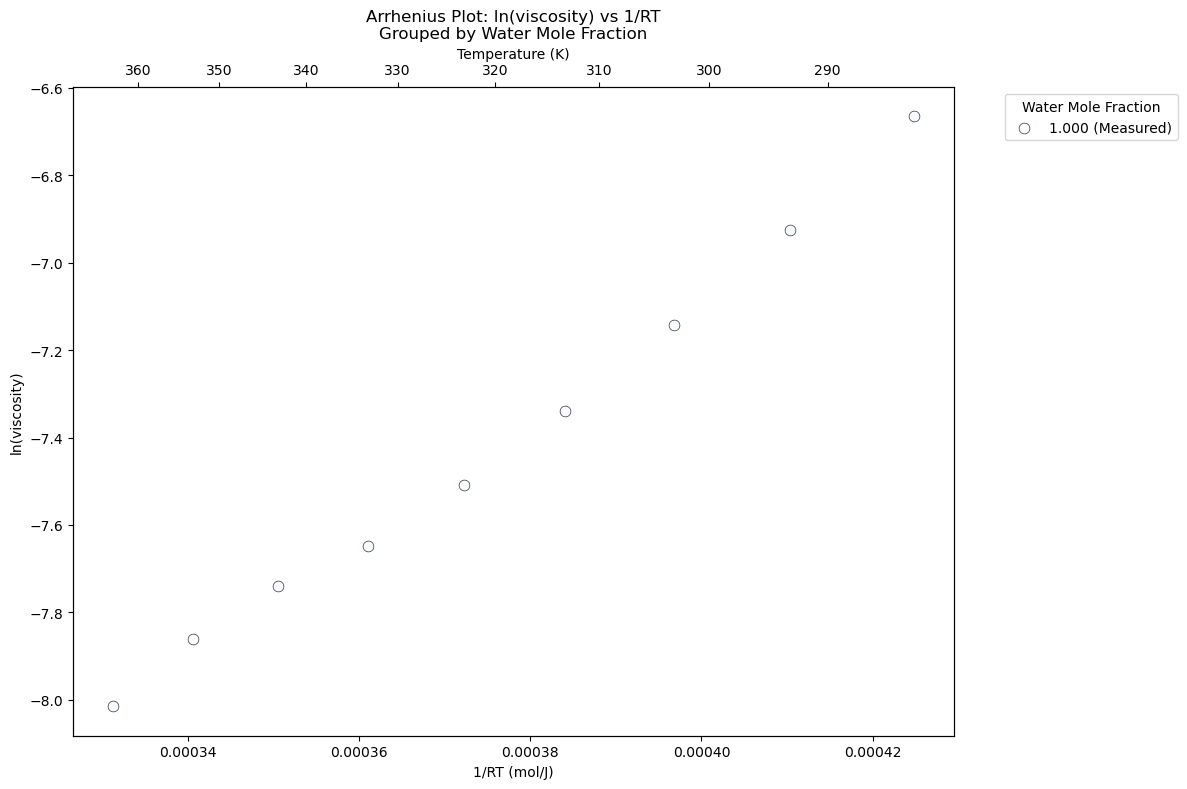

Combined dataset has 9 records

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi,ln_viscosity,inv_RT
0,17106d06-1cd7-4dcb-8de7-e4e8bc623c44,viscosity,0.000984,0.000005,None,1.0,None,293.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-6.924291,0.000410
1,3b1ff6df-7039-4f7c-9d9f-e6b6b480af29,viscosity,0.000477,0.000002,None,1.0,None,333.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-7.647994,0.000361
2,4ccfc557-3af1-4d14-a611-5a580a66b133,viscosity,0.000791,0.000004,None,1.0,None,303.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-7.141707,0.000397
3,54a37cda-99b2-4c5f-a5d0-3e557a971879,viscosity,0.000549,0.000003,None,1.0,None,323.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-7.507959,0.000372
4,5e7164a7-4386-47a8-8d1d-ecaa00544d23,viscosity,0.000386,0.000002,None,1.0,None,353.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-7.859673,0.000341
5,715401f2-50e7-4bcd-b37e-4b2457e83920,viscosity,0.000649,0.000003,None,1.0,None,313.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-7.339770,0.000384
6,829fe908-3c8c-4875-89ad-ec2e218c6ddc,viscosity,0.001274,0.000006,None,1.0,None,283.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-6.665672,0.000425
7,9cb4d0d9-5182-40fe-b9de-8f752878a443,viscosity,0.000435,0.000002,None,1.0,None,343.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-7.739245,0.000351
8,e58b323b-1099-462b-80a0-b23e2f9934e9,viscosity,0.000331,0.000002,None,1.0,None,363.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-8.014601,0.000331


In [8]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np

# Combine all three dataframes
combined_df = pd.concat([des_pure_df, water_df, des_water_df], ignore_index=True)

# Calculate ln(viscosity) and 1/RT
R = 8.314  # J/(mol·K) - gas constant
combined_df['ln_viscosity'] = np.log(combined_df['property_value'])
combined_df['inv_RT'] = 1 / (R * combined_df['temperature'])

# Fill NaN values in mole_fraction_water with 0 for proper coloring
combined_df['mole_fraction_water'] = combined_df['mole_fraction_water'].fillna(0)

# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Get unique water mole fractions and sort them
unique_water_fractions = sorted(combined_df['mole_fraction_water'].unique())

# Create a color map based on actual water fraction values
# Normalize the water fractions to [0, 1] range for color mapping
min_frac = min(unique_water_fractions)
max_frac = max(unique_water_fractions)
norm = plt.Normalize(vmin=min_frac, vmax=max_frac)
cmap = plt.cm.Blues

# Plot data for each unique water fraction
for water_frac in unique_water_fractions:
    # Filter data for this water fraction
    fraction_data = combined_df[combined_df['mole_fraction_water'] == water_frac]
    
    # Get color based on actual water fraction value
    color = cmap(norm(water_frac))
    
    # Separate by method
    measured_data = fraction_data[fraction_data['method'] == 'measured']
    simulated_data = fraction_data[fraction_data['method'] == 'simulated']
    
    # Plot measured data (circles)
    if len(measured_data) > 0:
        ax1.scatter(
            measured_data['inv_RT'], 
            measured_data['ln_viscosity'],
            color=color,
            marker='o',  # circles
            s=60,
            alpha=0.8,
            edgecolors='black',
            linewidth=0.5,
            label=f'{water_frac:.3f} (Measured)'
        )
    
    # Plot simulated data (squares)
    if len(simulated_data) > 0:
        ax1.scatter(
            simulated_data['inv_RT'], 
            simulated_data['ln_viscosity'],
            color=color,
            marker='s',  # squares
            s=60,
            alpha=0.8,
            edgecolors='black',
            linewidth=0.5,
            label=f'{water_frac:.3f} (Simulated)'
        )

ax1.set_xlabel('1/RT (mol/J)')
ax1.set_ylabel('ln(viscosity)')
ax1.set_title('Arrhenius Plot: ln(viscosity) vs 1/RT\nGrouped by Water Mole Fraction')
ax1.grid(False)

# Create second x-axis for temperature
ax2 = ax1.twiny()

# Get the actual data range for 1/RT
inv_rt_min = combined_df['inv_RT'].min()
inv_rt_max = combined_df['inv_RT'].max()

# Add some padding to the range
padding = (inv_rt_max - inv_rt_min) * 0.05
inv_rt_min_padded = inv_rt_min - padding
inv_rt_max_padded = inv_rt_max + padding

# Set the x-axis limits for both axes
ax1.set_xlim(inv_rt_min_padded, inv_rt_max_padded)
ax2.set_xlim(inv_rt_min_padded, inv_rt_max_padded)

# Convert 1/RT back to temperature for the top axis
temp_max = 1 / (R * inv_rt_min_padded)  # Note: inverse relationship
temp_min = 1 / (R * inv_rt_max_padded)

# Create temperature tick locations based on the actual data range
# Use reasonable temperature intervals
temp_range = temp_max - temp_min
if temp_range > 100:
    temp_interval = 20
elif temp_range > 50:
    temp_interval = 10
else:
    temp_interval = 5

# Generate temperature ticks
temp_start = int(temp_min / temp_interval) * temp_interval
temp_end = int(temp_max / temp_interval + 1) * temp_interval
temp_ticks = np.arange(temp_start, temp_end + temp_interval, temp_interval)

# Filter to only include temperatures within our range
temp_ticks = temp_ticks[(temp_ticks >= temp_min) & (temp_ticks <= temp_max)]

# Convert temperature ticks to 1/RT values for positioning
inv_rt_ticks = 1 / (R * temp_ticks)

# Set the ticks and labels
ax2.set_xticks(inv_rt_ticks)
ax2.set_xticklabels([f'{int(t)}' for t in temp_ticks])
ax2.set_xlabel('Temperature (K)')

# Add legend
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Water Mole Fraction')
plt.tight_layout()

plt.show()

# Display the combined dataframe
print(f"Combined dataset has {len(combined_df)} records")
combined_df

In [9]:
# Import der wiederverwendbaren Plot-Speicherfunktion
from fairfluids.core.plot_utils import save_plot_as_svg


Available columns:
[
    'experiment_id',
    'property_type',
    'property_value',
    'property_uncertainty',
    'mole_fraction_glycerol',
    'mole_fraction_water',
    'mole_fraction_cholinechloride',
    'temperature',
    'method',
    'source_file',
    'source_doi',
    'ln_viscosity',
    'inv_RT'
]

/tmp/ipykernel_69861/2984633200.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Water Mole Fraction')


ValueError: Axis limits cannot be NaN or Inf

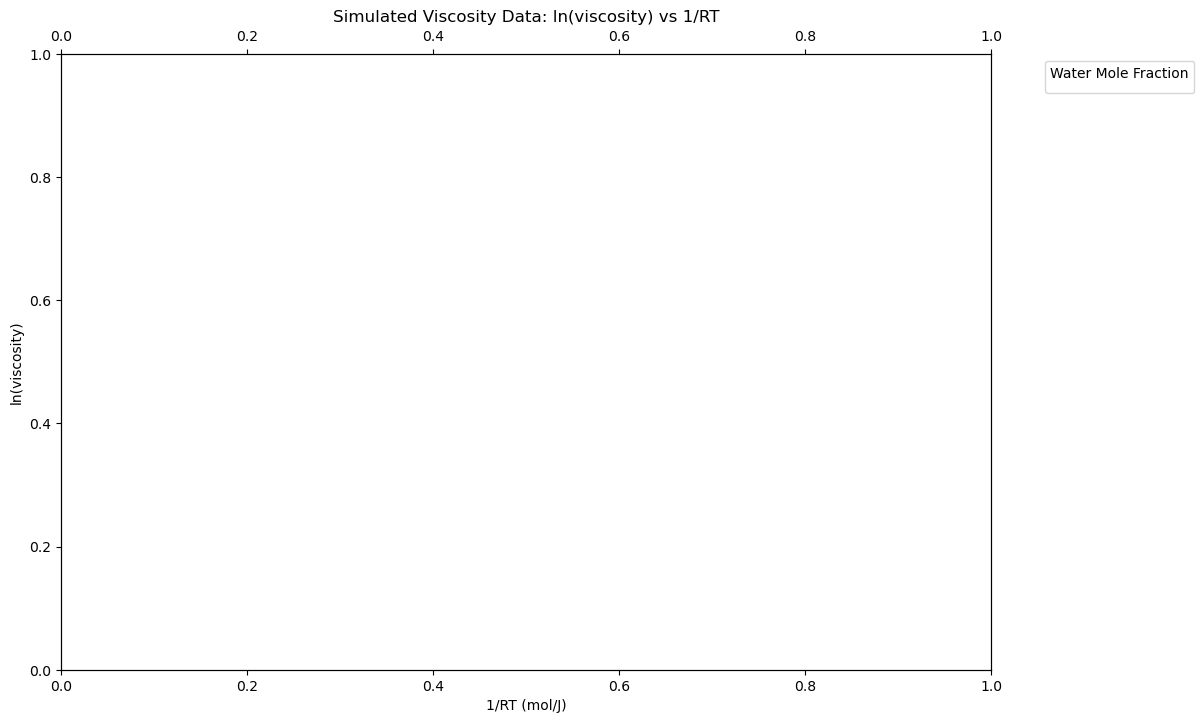

In [10]:
# Filter for simulated data only
simulated_df = combined_df[combined_df['method'] == 'simulated'].copy()

# Check what columns are available
print("Available columns:", simulated_df.columns.tolist())

# Plot simulated data
plt.figure(figsize=(12, 8))

# Create the main plot
ax1 = plt.gca()

# Check if we have a water mole fraction column (it might be named differently)
water_fraction_col = None
for col in simulated_df.columns:
    if 'water' in col.lower() and ('fraction' in col.lower() or 'mole' in col.lower()):
        water_fraction_col = col
        break

# Plot simulated data points
if water_fraction_col is not None:
    # Get unique water fractions and sort them
    unique_fractions = sorted(simulated_df[water_fraction_col].unique())
    
    # Create a color palette
    colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(unique_fractions)))
    
    # Plot each water fraction separately for legend
    for i, fraction in enumerate(unique_fractions):
        mask = simulated_df[water_fraction_col] == fraction
        ax1.scatter(simulated_df[mask]['inv_RT'], simulated_df[mask]['ln_viscosity'], 
                   alpha=0.7, s=50, color=colors[i],
                   edgecolors='black', linewidths=0.5,
                   label=f'{fraction:.3f}')
    
    # Add legend
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Water Mole Fraction')
else:
    # Plot without color coding if water fraction column not found
    scatter = ax1.scatter(simulated_df['inv_RT'], simulated_df['ln_viscosity'], 
                         alpha=0.7, s=50, label='Simulated', color='blue',
                         edgecolors='black', linewidths=0.5)
    ax1.legend()

# Set labels and title
ax1.set_xlabel('1/RT (mol/J)')
ax1.set_ylabel('ln(viscosity)')
ax1.set_title('Simulated Viscosity Data: ln(viscosity) vs 1/RT')

# Create secondary x-axis for temperature
ax2 = ax1.twiny()

# Calculate axis limits with padding
R = 8.314  # Gas constant
inv_rt_min = simulated_df['inv_RT'].min()
inv_rt_max = simulated_df['inv_RT'].max()
padding = (inv_rt_max - inv_rt_min) * 0.05
inv_rt_min_padded = inv_rt_min - padding
inv_rt_max_padded = inv_rt_max + padding

# Set the x-axis limits for both axes
ax1.set_xlim(inv_rt_min_padded, inv_rt_max_padded)
ax2.set_xlim(inv_rt_min_padded, inv_rt_max_padded)

# Convert 1/RT back to temperature for the top axis
temp_max = 1 / (R * inv_rt_min_padded)  # Note: inverse relationship
temp_min = 1 / (R * inv_rt_max_padded)

# Create temperature tick locations based on the actual data range
temp_range = temp_max - temp_min
if temp_range > 100:
    temp_interval = 20
elif temp_range > 50:
    temp_interval = 10
else:
    temp_interval = 5

# Generate temperature ticks
temp_start = int(temp_min / temp_interval) * temp_interval
temp_end = int(temp_max / temp_interval + 1) * temp_interval
temp_ticks = np.arange(temp_start, temp_end + temp_interval, temp_interval)

# Filter to only include temperatures within our range
temp_ticks = temp_ticks[(temp_ticks >= temp_min) & (temp_ticks <= temp_max)]

# Convert temperature ticks to 1/RT values for positioning
inv_rt_ticks = 1 / (R * temp_ticks)

# Set the ticks and labels
ax2.set_xticks(inv_rt_ticks)
ax2.set_xticklabels([f'{int(t)}' for t in temp_ticks])
ax2.set_xlabel('Temperature (K)')

plt.tight_layout()
save_plot_as_svg()
plt.show()

print(f"Simulated dataset has {len(simulated_df)} records")

<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8071/2847344150.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$')
/tmp/ipykernel_8071/2847344150.py:31: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')


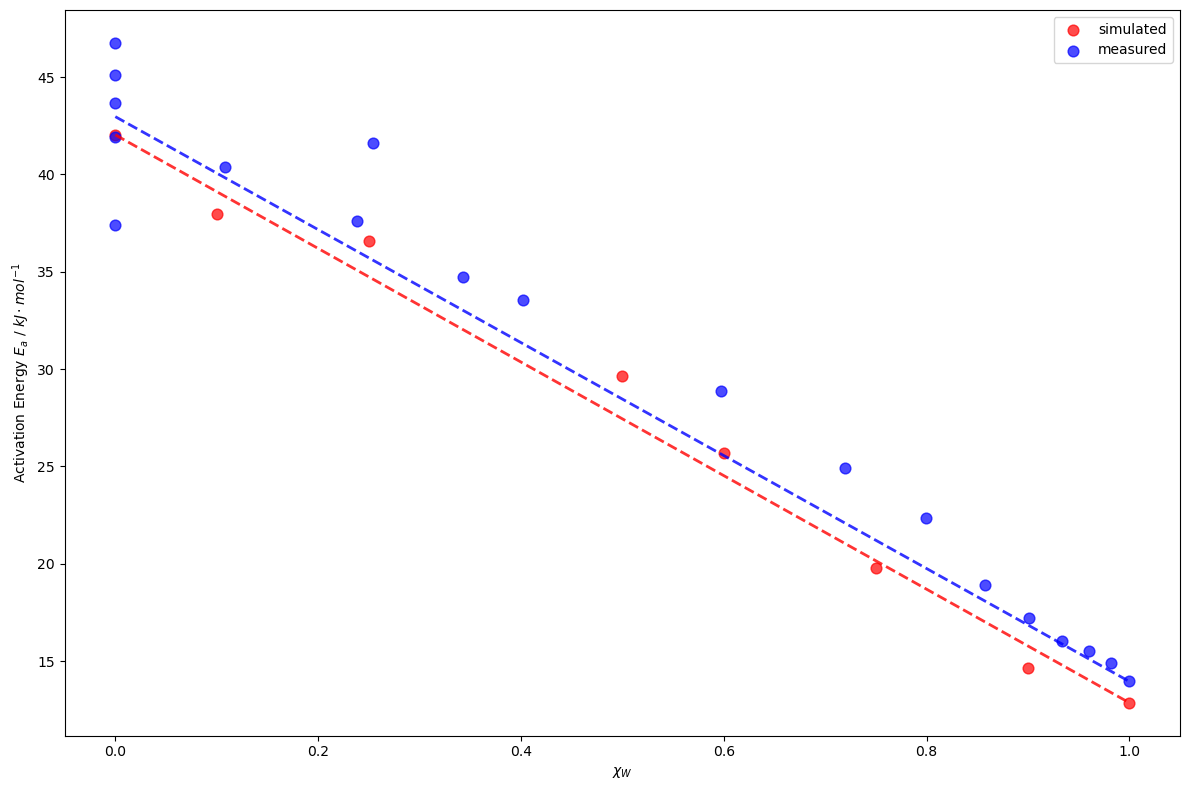

In [ ]:
# Plot activation energy vs water content, colored by method
plt.figure(figsize=(12, 8))

# Create scatter plot with red and blue colors
colors = ['red', 'blue']
for i, method in enumerate(activation_df['method'].unique()):
    method_data = activation_df[activation_df['method'] == method]
    plt.scatter(method_data['mole_fraction_water'], 
               method_data['activation_energy_J_mol'] / 1000,
               label=method, 
               alpha=0.7,
               s=60,
               color=colors[i % len(colors)])
    
    # Calculate mean activation energy for 0 and 1 mole fraction water
    water_0_data = method_data[method_data['mole_fraction_water'] == 0]
    water_1_data = method_data[method_data['mole_fraction_water'] == 1]
    
    if len(water_0_data) > 0 and len(water_1_data) > 0:
        mean_ea_0 = water_0_data['activation_energy_J_mol'].mean() / 1000
        mean_ea_1 = water_1_data['activation_energy_J_mol'].mean() / 1000
        
        # Connect the points with a line
        plt.plot([0, 1], [mean_ea_0, mean_ea_1], 
                color=colors[i % len(colors)], 
                linestyle='--', 
                alpha=0.8,
                linewidth=2)

plt.xlabel('$\chi_W$')
plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')
plt.legend()
plt.tight_layout()
save_plot_as_svg()
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\c'
<>:80: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\D'
<>:77: SyntaxWarning: invalid escape sequence '\c'
<>:80: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_8071/1378847495.py:77: SyntaxWarning: invalid escape sequence '\c'
  legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of $E_a$ at $\chi_W = 0$'))
/tmp/ipykernel_8071/1378847495.py:80: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('$\chi_W$')
/tmp/ipykernel_8071/1378847495.py:81: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$')


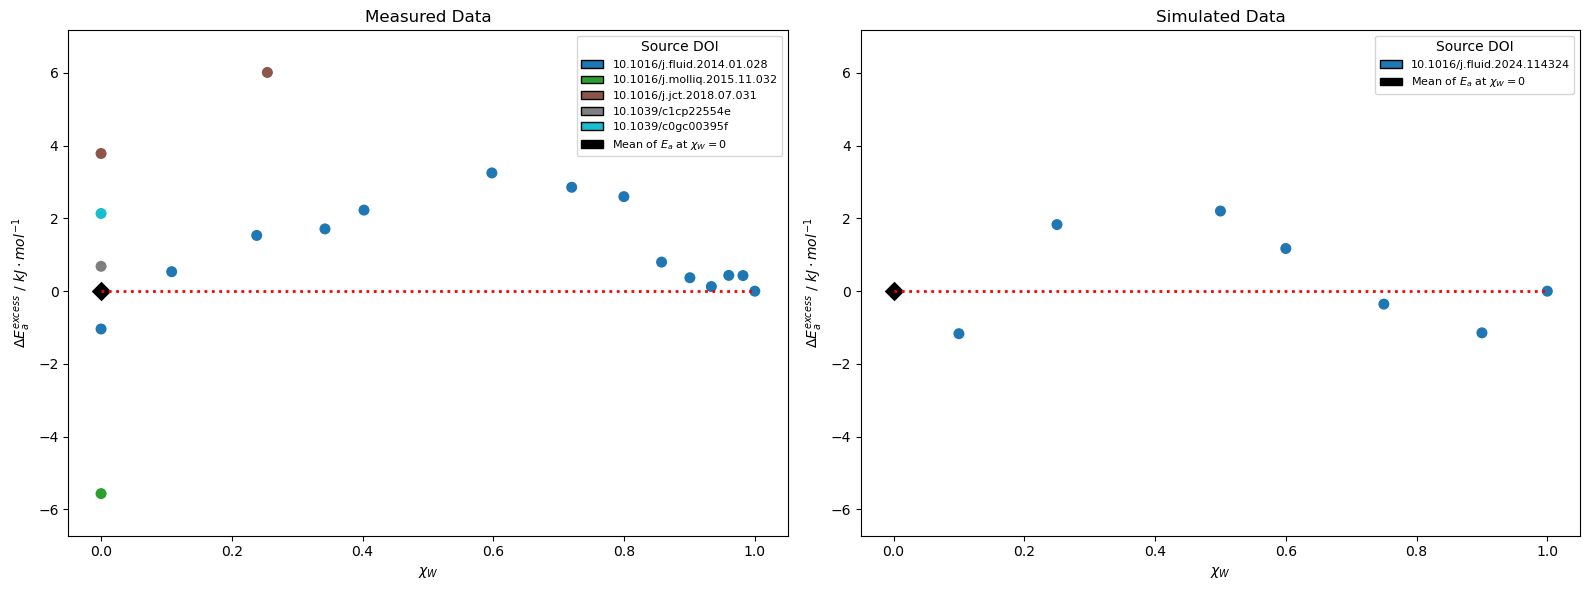

In [ ]:
# Plot excess activation energy vs water content, separated by method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Process each method separately
methods = activation_df['method'].unique()

# Store all residues to determine common y-axis limits
all_residues = []

for idx, method in enumerate(methods):
    ax = ax1 if method == 'measured' else ax2
    method_data = activation_df[activation_df['method'] == method]
    
    # Calculate mean activation energy for zero and one water content (in J/mol)
    mean_0_water = method_data[method_data['mole_fraction_water'] == 0.0]['activation_energy_J_mol'].mean()
    mean_1_water = method_data[method_data['mole_fraction_water'] == 1.0]['activation_energy_J_mol'].mean()
    
    # Calculate the linear trend line values for each data point
    water_fractions = method_data['mole_fraction_water']
    trend_line_values = mean_0_water + (mean_1_water - mean_0_water) * water_fractions
    
    # Calculate residues (excess activation energy) in kJ/mol
    residues = (method_data['activation_energy_J_mol'] - trend_line_values) / 1000
    all_residues.extend(residues)
    
    # Separate zero water content data
    zero_water_mask = method_data['mole_fraction_water'] == 0.0
    other_mask = method_data['mole_fraction_water'] != 0.0
    
    # Create color map for DOIs
    unique_dois = method_data['source_doi'].unique()
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_dois)))
    doi_colors = {doi: colors_map[i] for i, doi in enumerate(unique_dois)}
    method_data_colors = method_data['source_doi'].map(doi_colors)
    
    # Plot zero water content points
    if zero_water_mask.any():
        ax.scatter(
            method_data[zero_water_mask]['mole_fraction_water'],
            residues[zero_water_mask],
            c=[doi_colors[doi] for doi in method_data[zero_water_mask]['source_doi']],
            s=80,
            edgecolor='w'
        )
    
    # Plot the mean point for zero water content
    zero_water_residue = (mean_0_water - mean_0_water) / 1000  # This will be 0
    ax.scatter(
        0.0,
        zero_water_residue,
        c='black',
        s=120,
        edgecolor='w',
        marker='D',
        label='Mean (0% water)'
    )
    
    # Plot other data points colored by DOI
    if other_mask.any():
        ax.scatter(
            method_data[other_mask]['mole_fraction_water'],
            residues[other_mask],
            c=[doi_colors[doi] for doi in method_data[other_mask]['source_doi']],
            s=80,
            edgecolor='w'
        )
    
    # Add dotted red line connecting mean at mole fraction 0 to mole fraction 1
    one_water_residue = (mean_1_water - (mean_0_water + (mean_1_water - mean_0_water) * 1.0)) / 1000
    ax.plot([0.0, 1.0], [zero_water_residue, one_water_residue], 'r:', linewidth=2, label='Mean trend')
    
    # Create legend for DOIs
    from matplotlib.patches import Patch
    legend_handles = []
    for doi in unique_dois:
        legend_handles.append(Patch(facecolor=doi_colors[doi], edgecolor='k', label=f"{doi}"))
    legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of $E_a$ at $\chi_W = 0$'))
    
    ax.legend(handles=legend_handles, title="Source DOI", fontsize=8)
    ax.set_xlabel('$\chi_W$')
    ax.set_ylabel('$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$')
    ax.set_title(f'{method.capitalize()} Data')

# Set common y-axis limits for both subplots
y_min = min(all_residues)
y_max = max(all_residues)
y_margin = (y_max - y_min) * 0.1
ax1.set_ylim(y_min - y_margin, y_max + y_margin)
ax2.set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
save_plot_as_svg()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8071/2694142281.py:16: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $J \cdot mol^{-1}$')


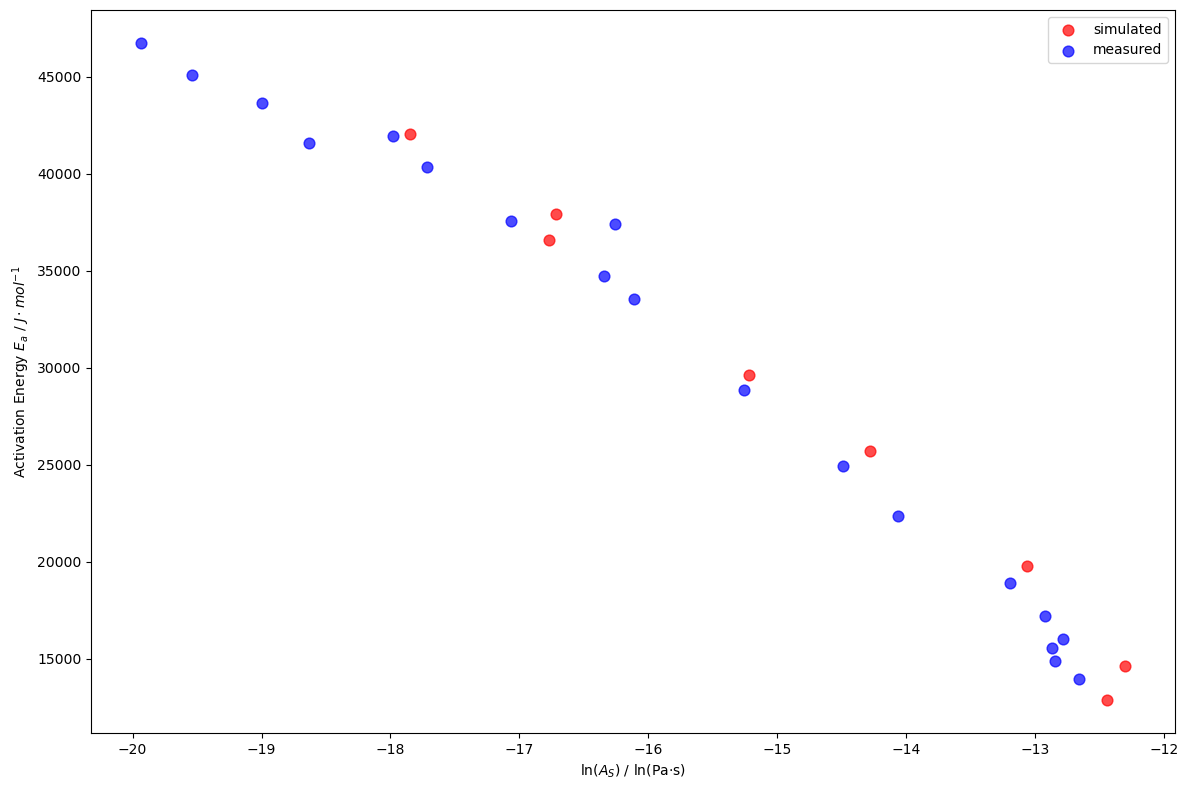

In [ ]:
# Plot activation energy vs ln(A) colored by method
plt.figure(figsize=(12, 8))

# Create scatter plot with red and blue colors
colors = ['red', 'blue']
for i, method in enumerate(activation_df['method'].unique()):
    method_data = activation_df[activation_df['method'] == method]
    plt.scatter(method_data['ln_pre_exponential'], 
               method_data['activation_energy_J_mol'],
               label=method, 
               alpha=0.7,
               s=60,
               color=colors[i % len(colors)])

plt.xlabel('ln($A_S$) / ln(Pa·s)')
plt.ylabel('Activation Energy $E_a$ / $J \cdot mol^{-1}$')
plt.legend()
plt.tight_layout()
save_plot_as_svg()
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8071/345008102.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$ Mole Fraction Water')


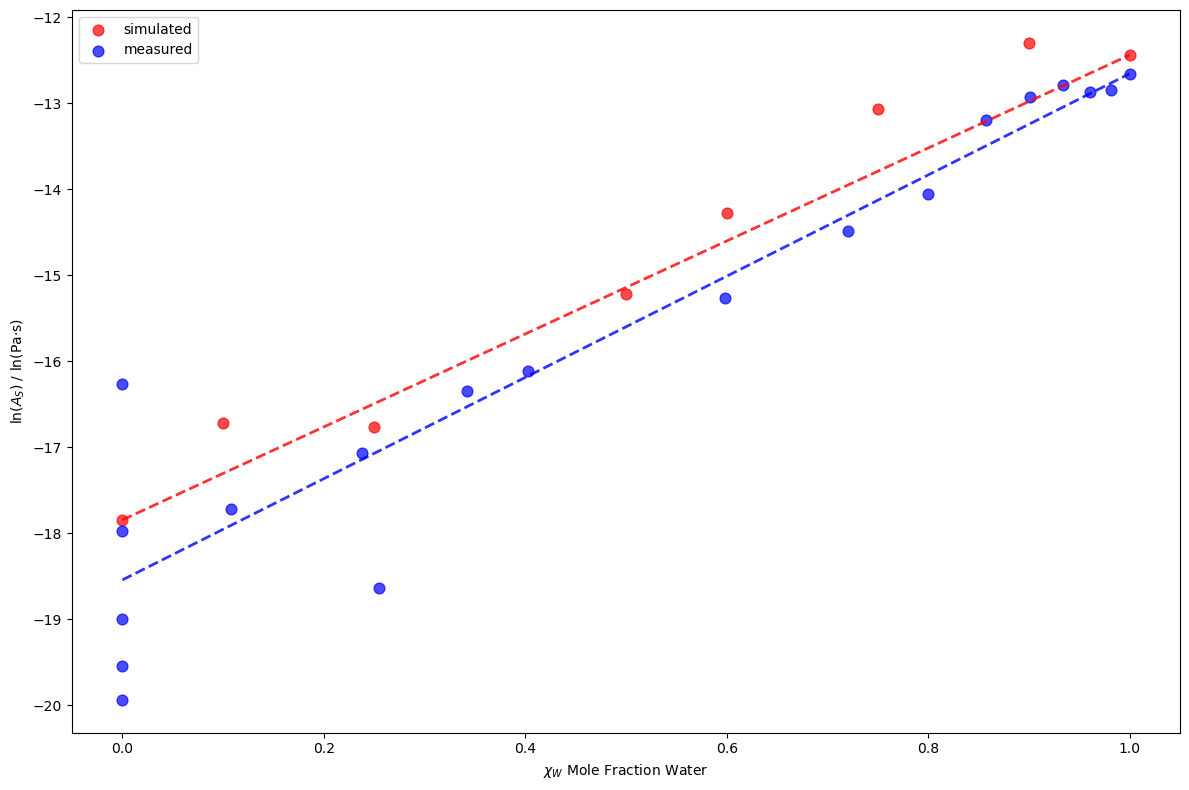

In [ ]:
# Plot ln(A) vs mole fraction water colored by method
plt.figure(figsize=(12, 8))

# Create scatter plot with red and blue colors
colors = ['red', 'blue']
for i, method in enumerate(activation_df['method'].unique()):
    method_data = activation_df[activation_df['method'] == method]
    plt.scatter(method_data['mole_fraction_water'], 
               method_data['ln_pre_exponential'],
               label=method, 
               alpha=0.7,
               s=60,
               color=colors[i % len(colors)])
    
    # Calculate mean ln(A) for 0 and 1 mole fraction water
    water_0_data = method_data[method_data['mole_fraction_water'] == 0]
    water_1_data = method_data[method_data['mole_fraction_water'] == 1]
    
    if len(water_0_data) > 0 and len(water_1_data) > 0:
        mean_lnA_0 = water_0_data['ln_pre_exponential'].mean()
        mean_lnA_1 = water_1_data['ln_pre_exponential'].mean()
        
        # Connect the points with a line
        plt.plot([0, 1], [mean_lnA_0, mean_lnA_1], 
                color=colors[i % len(colors)], 
                linestyle='--', 
                alpha=0.8,
                linewidth=2)

plt.xlabel('$\chi_W$ Mole Fraction Water')
plt.ylabel('ln($A_S$) / ln(Pa·s)')
plt.legend()
plt.tight_layout()
save_plot_as_svg()
plt.show()

In [ ]:
# Use the combined_df from earlier cells and filter for high temperature group
# First, recreate the split logic if needed

# Create a composition identifier from mole fractions for grouping
def get_composition_key(row):
    """Convert mole fractions to a hashable tuple for grouping."""
    # Collect all mole fraction columns
    mf_cols = ['mole_fraction_glycerol', 'mole_fraction_water', 'mole_fraction_cholinechloride']
    mf_values = []
    for col in mf_cols:
        if col in row.index and pd.notna(row[col]):
            mf_values.append(round(float(row[col]), 3))
    return tuple(mf_values) if mf_values else None

combined_df['composition_key'] = combined_df.apply(get_composition_key, axis=1)

# Get unique combinations of DOI and composition
doi_composition_combinations = combined_df[
    combined_df['composition_key'].notna() &
    combined_df['source_doi'].notna() &
    (~combined_df["inv_RT"].isna()) &
    (~combined_df["ln_viscosity"].isna())
][['source_doi', 'composition_key']].drop_duplicates()

# List to store all split data
split_data = []

# Process each valid DOI-composition combination - split into temperature groups (High T and Low T)
for _, row in doi_composition_combinations.iterrows():
    doi = row['source_doi']
    comp_key = row['composition_key']
    
    subset = combined_df[
        (combined_df["source_doi"] == doi) &
        (combined_df["composition_key"] == comp_key) &
        (~combined_df["inv_RT"].isna()) &
        (~combined_df["ln_viscosity"].isna())
    ]
    
    if len(subset) < 2:
        continue  # Not enough points to split
    
    # Check if this is simulated data
    method = subset['method'].iloc[0]
    
    if method == 'simulated':
        # Keep simulated data complete without splitting
        subset_copy = subset.copy()
        subset_copy['temperature_group'] = 'High T'
        split_data.append(subset_copy)
    else:
        # Split measured data into two halves based on temperature
        # Sort by temperature (inverse of inv_RT for proper ordering)
        subset_sorted = subset.sort_values('inv_RT')
        
        # Split into two halves based on temperature
        n_points = len(subset_sorted)
        mid_point = n_points // 2
        
        # Lower half (higher temperatures - lower inv_RT values)
        low_temp_group = subset_sorted.iloc[:mid_point].copy()
        low_temp_group['temperature_group'] = 'High T'
        
        # Upper half (lower temperatures - higher inv_RT values)  
        high_temp_group = subset_sorted.iloc[mid_point:].copy()
        high_temp_group['temperature_group'] = 'Low T'
        
        # Add to split_data list
        split_data.append(low_temp_group)
        split_data.append(high_temp_group)

# Combine all split data into a single DataFrame
split_points_df = pd.concat(split_data, ignore_index=True)

# Filter for High T temperature group only
high_temp_df = split_points_df[split_points_df['temperature_group'] == 'High T'].copy()

print(f"High temperature data shape: {high_temp_df.shape}")
print(f"Number of unique DOI-composition combinations: {high_temp_df[['source_doi', 'composition_key']].drop_duplicates().shape[0]}")
display(high_temp_df.head(10))

High temperature data shape: (133, 15)

Number of unique DOI-composition combinations: 27

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi,ln_viscosity,inv_RT,composition_key,temperature_group
0,e2f84b2e-9823-474e-a97d-0c4ee5e55b63,viscosity,0.04094,0.000819,0.666667,0.0,0.333333,338.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-3.195648,0.000356,"(0.667, 0.0, 0.333)",High T
1,d66c103f-3bd6-457c-8308-7ba54b39962d,viscosity,0.04519,0.000904,0.666667,0.0,0.333333,335.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-3.096879,0.000358,"(0.667, 0.0, 0.333)",High T
2,2fd83554-a868-4c0d-b1a3-42c297bf9e22,viscosity,0.05005,0.001001,0.666667,0.0,0.333333,333.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.994733,0.000361,"(0.667, 0.0, 0.333)",High T
3,1f71b285-9cc2-4d35-877b-530c6a1794fb,viscosity,0.05563,0.001113,0.666667,0.0,0.333333,330.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.889033,0.000364,"(0.667, 0.0, 0.333)",High T
4,12bf784b-1496-4798-9f50-2a1091130712,viscosity,0.06206,0.001241,0.666667,0.0,0.333333,328.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.779654,0.000367,"(0.667, 0.0, 0.333)",High T
5,aa9d3ba7-3c6a-48c3-817a-b866cfa0753c,viscosity,0.06946,0.001389,0.666667,0.0,0.333333,325.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.667004,0.000369,"(0.667, 0.0, 0.333)",High T
6,1dccada7-2f23-4c8f-8cc4-2b52334e855f,viscosity,0.07839,0.001568,0.666667,0.0,0.333333,323.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.546059,0.000372,"(0.667, 0.0, 0.333)",High T
7,5467e7b9-c042-471b-ad21-9f40e4159d75,viscosity,0.08843,0.001769,0.666667,0.0,0.333333,320.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.425544,0.000375,"(0.667, 0.0, 0.333)",High T
8,d30cbcce-e74b-4eb0-973e-9fd7aec3b712,viscosity,0.10000,0.002000,0.666667,0.0,0.333333,318.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.302585,0.000378,"(0.667, 0.0, 0.333)",High T
9,0211680d-87a7-44a4-a5a4-e3970990bee4,viscosity,0.11380,0.002276,0.666667,0.0,0.333333,315.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.173313,0.000381,"(0.667, 0.0, 0.333)",High T


In [ ]:
# Check temperature range for simulated data in high_temp_df
simulated_high_temp = high_temp_df[high_temp_df['method'] == 'simulated']
if len(simulated_high_temp) > 0:
    min_temp = simulated_high_temp['temperature'].min()
    max_temp = simulated_high_temp['temperature'].max()
    print(f"Simulated data temperature range: {min_temp:.2f} K to {max_temp:.2f} K")
    print(f"Number of simulated points: {len(simulated_high_temp)}")
else:
    print("No simulated data found in high_temp_df")


Simulated data temperature range: 313.15 K to 353.15 K

Number of simulated points: 40

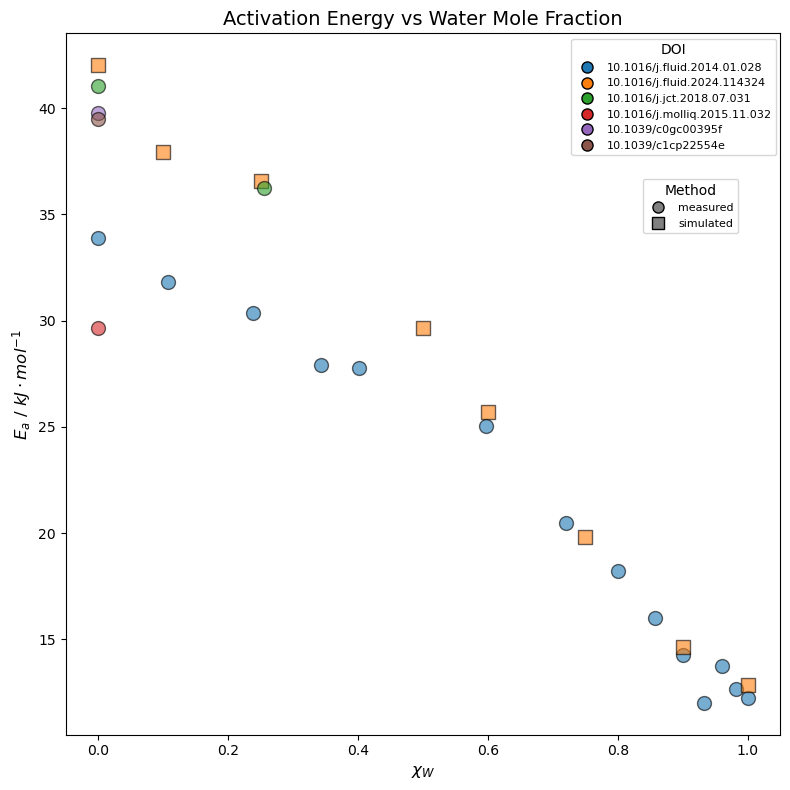

Calculated activation energies for 27 high-temperature composition-DOI combinations

,source_doi,composition_key,mole_fraction_water,method,activation_energy_J_mol,ln_pre_exponential,r_squared,p_value,n_points
13,10.1016/j.fluid.2014.01.028,"(0.667, 0.0, 0.333)",0.000000,measured,33879.814347,-15.165900,0.999022,4.889805e-04,4
25,10.1039/c0gc00395f,"(0.667, 0.0, 0.333)",0.000000,measured,39776.179434,-17.542429,0.999304,3.479948e-04,4
21,10.1016/j.fluid.2024.114324,"(0.667, 0.0, 0.333)",0.000000,simulated,42029.324327,-17.845349,0.989444,4.617843e-04,5
26,10.1039/c1cp22554e,"(0.667, 0.0, 0.333)",0.000000,measured,39512.914778,-17.451681,0.998239,2.671985e-02,3
24,10.1016/j.molliq.2015.11.032,"(0.667, 0.0, 0.333)",0.000000,measured,29642.977920,-13.525274,0.975107,2.343343e-04,6
23,10.1016/j.jct.2018.07.031,"(0.667, 0.0, 0.333)",0.000000,measured,41070.883460,-17.823342,0.999330,3.322528e-17,12
20,10.1016/j.fluid.2024.114324,"(0.6, 0.1, 0.3)",0.100000,simulated,37944.135877,-16.718555,0.992833,2.580915e-04,5
12,10.1016/j.fluid.2014.01.028,"(0.595, 0.108, 0.297)",0.108000,measured,31815.470321,-14.733084,0.998983,5.087028e-04,4
11,10.1016/j.fluid.2014.01.028,"(0.508, 0.238, 0.254)",0.238100,measured,30343.060020,-14.530880,0.999396,3.019892e-04,4
19,10.1016/j.fluid.2024.114324,"(0.5, 0.25, 0.25)",0.250000,simulated,36568.253101,-16.767117,0.994475,1.745761e-04,5


In [ ]:
# Calculate activation energies for high temperature data using scipy.stats.linregress
from scipy import stats

high_temp_results = []

for (doi, comp_key), group in high_temp_df.groupby(['source_doi', 'composition_key']):
    if len(group) > 2:
        # Perform linear regression: ln(viscosity) = A + B*(1/RT)
        slope, intercept, r_value, p_value, std_err = stats.linregress(group['inv_RT'], group['ln_viscosity'])
        
        activation_energy = slope
        ln_pre_exponential = intercept
        
        # Get water mole fraction and method
        water_frac = group['mole_fraction_water'].iloc[0]
        method = group['method'].iloc[0]
        
        high_temp_results.append({
            'source_doi': doi,
            'composition_key': comp_key,
            'mole_fraction_water': water_frac,
            'method': method,
            'activation_energy_J_mol': activation_energy,
            'ln_pre_exponential': ln_pre_exponential,
            'r_squared': r_value**2,
            'p_value': p_value,
            'n_points': len(group)
        })

high_temp_ea_df = pd.DataFrame(high_temp_results)

# Plot activation energy vs water mole fraction with color by DOI and shape by method
plt.figure(figsize=(8, 8))

# Get unique DOIs and methods for color and marker mapping
unique_dois = high_temp_ea_df['source_doi'].unique()
unique_methods = high_temp_ea_df['method'].unique()

# Create color map for DOIs
colors = plt.cm.tab10(range(len(unique_dois)))
doi_color_map = dict(zip(unique_dois, colors))

# Create marker map for methods
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
method_marker_map = dict(zip(unique_methods, markers[:len(unique_methods)]))

# Plot each point with appropriate color and marker
for _, row in high_temp_ea_df.iterrows():
    plt.scatter(row['mole_fraction_water'], row['activation_energy_J_mol'] / 1000,
                c=[doi_color_map[row['source_doi']]], 
                marker=method_marker_map[row['method']],
                s=100, alpha=0.6, edgecolors='black')

# Create legends
from matplotlib.lines import Line2D
# DOI legend (colors)
doi_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=doi_color_map[doi], markersize=8, 
                              label=doi, markeredgecolor='black')
                       for doi in unique_dois]
# Method legend (shapes)
method_legend_elements = [Line2D([0], [0], marker=method_marker_map[method], color='w',
                                 markerfacecolor='gray', markersize=8,
                                 label=method, markeredgecolor='black')
                          for method in unique_methods]

# Add both legends
first_legend = plt.legend(handles=doi_legend_elements, title='DOI', 
                         loc='upper left', bbox_to_anchor=(0.7, 1), fontsize=8)
plt.gca().add_artist(first_legend)
plt.legend(handles=method_legend_elements, title='Method',
          loc='upper left', bbox_to_anchor=(0.8, 0.8), fontsize=8)

plt.xlabel(r'$\chi_W$', fontsize=12)
plt.ylabel(r'$E_a$ / $kJ \cdot mol^{-1}$', fontsize=12)
plt.title('Activation Energy vs Water Mole Fraction', fontsize=14)
plt.tight_layout()
save_plot_as_svg()
plt.show()

print(f"Calculated activation energies for {len(high_temp_ea_df)} high-temperature composition-DOI combinations")
display(high_temp_ea_df.sort_values('mole_fraction_water'))


In [ ]:
# Filter for High T temperature group only
high_temp_df = split_points_df[split_points_df['temperature_group'] == 'High T'].copy()

Steigung m = 1399.5002 ± 79.4241
Aktivierungsenergie E_A = 11635.44 ± 660.33 J/mol


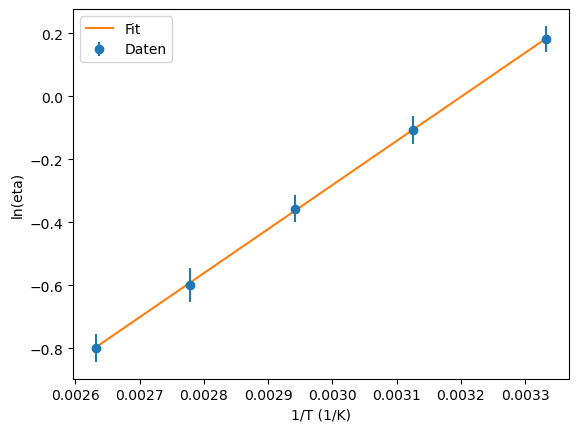

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Beispiel-Daten ---
T = np.array([300, 320, 340, 360, 380])  # Temperatur in K
eta = np.array([1.2, 0.9, 0.7, 0.55, 0.45])  # Viskosität
sigma_eta = np.array([0.05, 0.04, 0.03, 0.03, 0.02])  # Fehler auf eta

R = 8.314  # J/(mol*K)

# --- Linearisierung ---
x = 1 / T
y = np.log(eta)

# Fehlerfortpflanzung: sigma_ln(eta) = sigma_eta / eta
sigma_y = sigma_eta / eta

# Gewichte
w = 1 / sigma_y**2

# --- Gewichteter linearer Fit ---
# Formeln für weighted least squares
W = np.sum(w)
Wx = np.sum(w * x)
Wy = np.sum(w * y)
Wxx = np.sum(w * x * x)
Wxy = np.sum(w * x * y)

Delta = W * Wxx - Wx**2

m = (W * Wxy - Wx * Wy) / Delta
b = (Wxx * Wy - Wx * Wxy) / Delta

# Fehler der Steigung
sigma_m = np.sqrt(W / Delta)

# --- Aktivierungsenergie ---
E_A = m * R
sigma_E_A = sigma_m * R

print(f"Steigung m = {m:.4f} ± {sigma_m:.4f}")
print(f"Aktivierungsenergie E_A = {E_A:.2f} ± {sigma_E_A:.2f} J/mol")

# --- Plot ---
plt.errorbar(x, y, yerr=sigma_y, fmt='o', label='Daten')
x_fit = np.linspace(min(x), max(x), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, label='Fit')

plt.xlabel("1/T (1/K)")
plt.ylabel("ln(eta)")
plt.legend()
plt.show()